# Import librerie e setup variabili

Download dei dati da Yahoo Finance, con definizione di un intervallo di date e di una lista di titoli. I dati vengono organizzati in una lista di tuple (ticker, dataframe) per facilitare l'elaborazione successiva.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import datetime as dt
from IPython.display import display
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
# import pandas_datareader.data as web
import urllib.request
import zipfile
import os
import sys

sys.path.append('./src')
import utils


start_date = dt.datetime(2016, 3, 31)
end_date = dt.datetime(2026, 3, 31)
stocks = ['MSFT', 'NVDA', 'TSLA', 'GM', 'XOM', 'NEE']
stock_list = []

data = yf.download(stocks, start=start_date, end=end_date)
for t in data.columns.get_level_values('Ticker').unique():
    ticker = data.xs(t, axis=1, level = 'Ticker', drop_level=True)
    stock_list.append((t, ticker))

data.head()

[*********************100%***********************]  6 of 6 completed


Price           Close                                                        \
Ticker             GM       MSFT        NEE      NVDA       TSLA        XOM   
Date                                                                          
2016-03-31  25.543207  48.491245  22.920952  0.872227  15.318000  53.705700   
2016-04-01  24.763014  48.789768  22.992603  0.884956  15.839333  53.300938   
2016-04-04  24.299774  48.666847  22.994545  0.876388  16.466000  53.429436   
2016-04-05  24.055960  47.902996  22.535503  0.875164  17.031334  52.819088   
2016-04-06  24.332281  48.394669  22.605232  0.876388  17.694668  53.525818   

Price            High                                  ...       Open  \
Ticker             GM       MSFT        NEE      NVDA  ...        NEE   
Date                                                   ...              
2016-03-31  25.673239  48.807321  23.010049  0.881285  ...  22.901583   
2016-04-01  25.356287  48.824889  23.046835  0.885446  ...  22.872517   
2016-04-04  24.771141  48.868784  23.083641  0.896952  ...  23.054588   
2016-04-05  24.161610  48.552705  23.029406  0.883243  ...  22.913194   
2016-04-06  24.340408  48.464909  22.611043  0.876878  ...  22.529694   

Price                                         Volume                     \
Ticker          NVDA       TSLA        XOM        GM      MSFT      NEE   
Date                                                                      
2016-03-31  0.879326  15.289333  54.014097  10209000  26360500  8025600   
2016-04-01  0.866841  16.322001  52.941145  17421700  24399200  8320800   
2016-04-04  0.892300  16.608000  53.365183  12167300  18928800  5239600   
2016-04-05  0.868555  16.033333  53.076085   9101900  19272300  8802800   
2016-04-06  0.864148  16.931334  53.127477   9620300  21188700  6557200   

Price                                       
Ticker           NVDA       TSLA       XOM  
Date                                        
2016-03-31  379884000  120193500  13896900  
2016-04-01  348292000  239962500  12235300  
2016-04-04  393940000  202129500   8050200  
2016-04-05  339568000  149230500  10446800  
2016-04-06  453376000  175582500   9320200  

[5 rows x 30 columns]

## Esportazione dei dati

Esportazione dei dati scaricati da Yahoo Finance in file CSV, uno per ogni titolo.

In [2]:
for t, df in stock_list:
    df.to_csv(f'./data/{t}.csv')

# Presentazione dei dati

Visualizzazione dei primi 5 record di ogni dataframe, insieme al nome del ticker. Visualizzato un grafico del prezzo di chiusura per ogni titolo.

'Ticker: GM'

Price,Close,High,Low,Open,Volume
Date,,,,,
2016-03-31,25.543207,25.673239,25.193745,25.201872,10209000
2016-04-01,24.763014,25.356287,24.641109,25.340033,17421700
2016-04-04,24.299774,24.771141,24.177869,24.706125,12167300
2016-04-05,24.055960,24.161610,23.852784,24.112849,9101900
2016-04-06,24.332281,24.340408,23.812151,24.104724,9620300
2016-04-07,23.909674,24.340406,23.714626,24.259136,12865600
2016-04-08,23.869047,24.186000,23.755268,24.112857,8843500


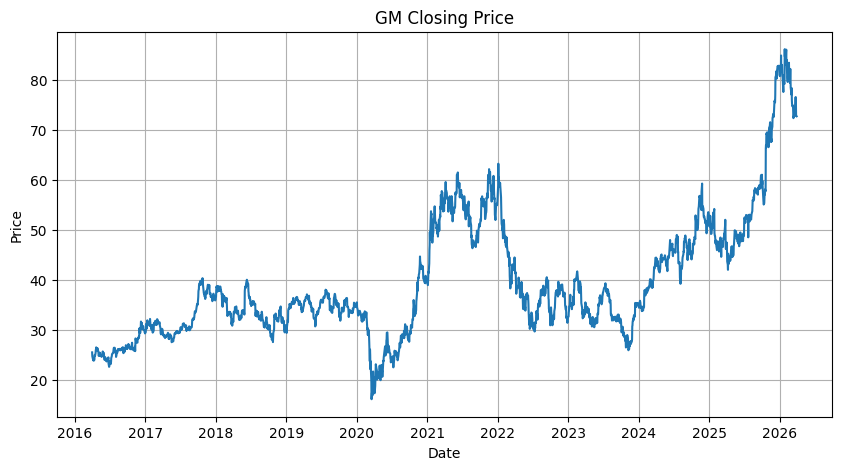

'Ticker: MSFT'

Price,Close,High,Low,Open,Volume
Date,,,,,
2016-03-31,48.491245,48.807321,48.166391,48.245410,26360500
2016-04-01,48.789768,48.824889,47.911781,48.333214,24399200
2016-04-04,48.666847,48.868784,48.289312,48.666847,18928800
2016-04-05,47.902996,48.552705,47.815195,48.456126,19272300
2016-04-06,48.394669,48.464909,47.595700,47.727400,21188700
2016-04-07,47.815201,48.210296,47.613264,48.175176,19225100
2016-04-08,47.780071,48.535141,47.692274,47.999568,22167200


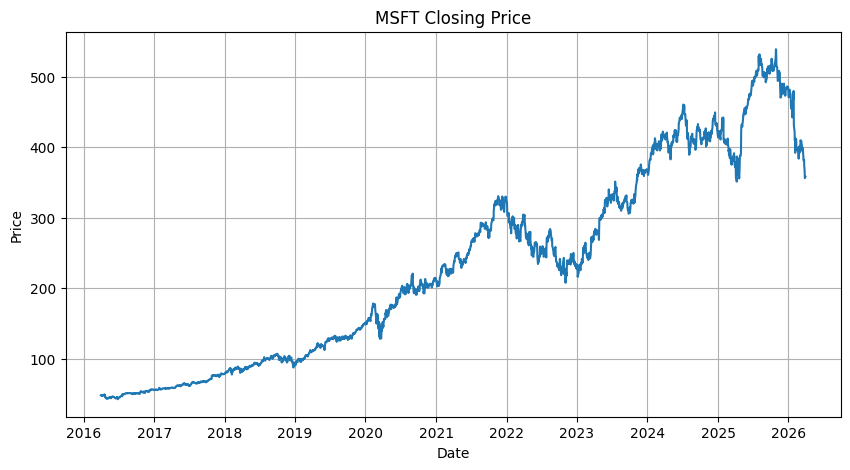

'Ticker: NEE'

Price,Close,High,Low,Open,Volume
Date,,,,,
2016-03-31,22.920952,23.010049,22.826045,22.901583,8025600
2016-04-01,22.992603,23.046835,22.750494,22.872517,8320800
2016-04-04,22.994545,23.083641,22.843469,23.054588,5239600
2016-04-05,22.535503,23.029406,22.496767,22.913194,8802800
2016-04-06,22.605232,22.611043,22.386366,22.529694,6557200
2016-04-07,22.504522,22.721451,22.465784,22.539386,5359600
2016-04-08,22.624607,22.746631,22.465784,22.465784,4268800


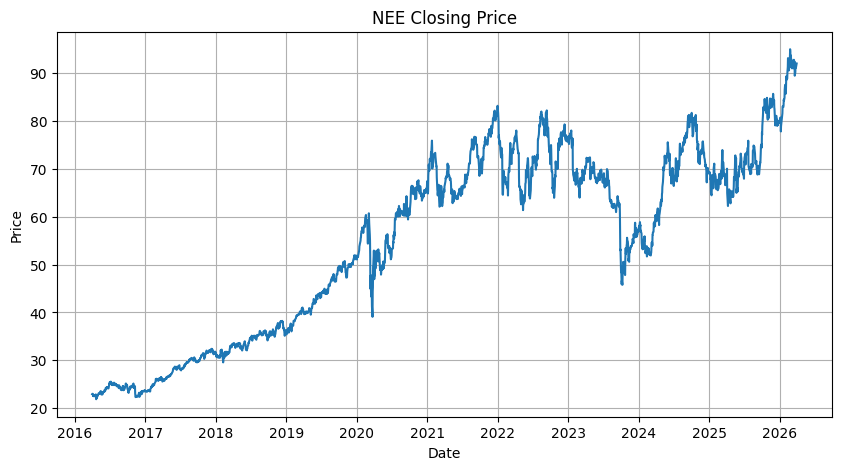

'Ticker: NVDA'

Price,Close,High,Low,Open,Volume
Date,,,,,
2016-03-31,0.872227,0.881285,0.865373,0.879326,379884000
2016-04-01,0.884956,0.885446,0.860231,0.866841,348292000
2016-04-04,0.876388,0.896952,0.872961,0.892300,393940000
2016-04-05,0.875164,0.883243,0.865128,0.868555,339568000
2016-04-06,0.876388,0.876878,0.847747,0.864148,453376000
2016-04-07,0.867331,0.878592,0.863659,0.870758,378104000
2016-04-08,0.872961,0.880060,0.864393,0.874430,255936000


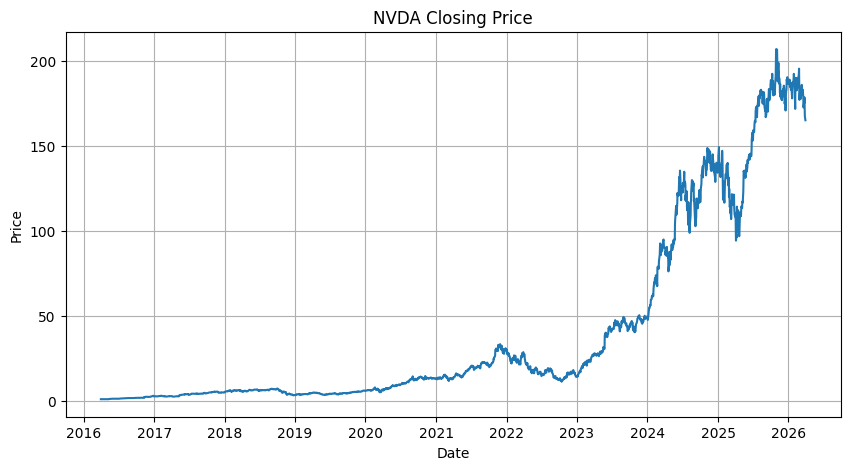

'Ticker: TSLA'

Price,Close,High,Low,Open,Volume
Date,,,,,
2016-03-31,15.318000,15.828000,15.000667,15.289333,120193500
2016-04-01,15.839333,16.526667,15.550000,16.322001,239962500
2016-04-04,16.466000,16.808001,16.242666,16.608000,202129500
2016-04-05,17.031334,17.104000,16.000000,16.033333,149230500
2016-04-06,17.694668,17.849333,16.896667,16.931334,175582500
2016-04-07,17.146667,17.955999,16.967333,17.763332,132843000
2016-04-08,16.671333,17.388000,16.534666,17.366667,110458500


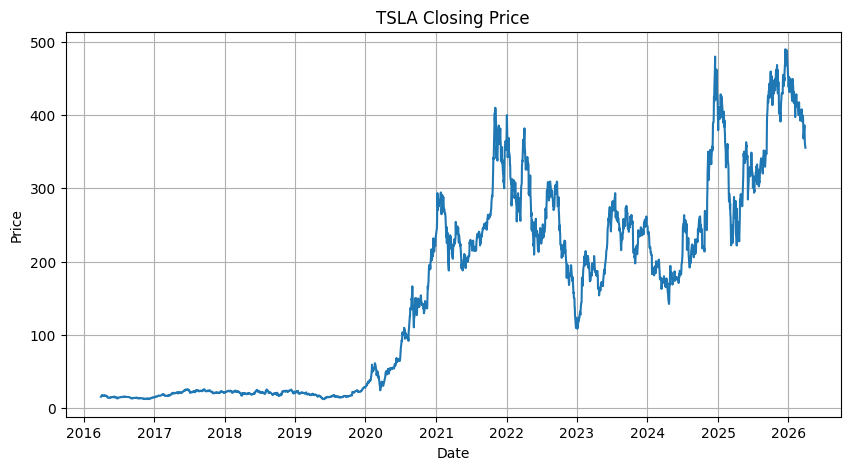

'Ticker: XOM'

Price,Close,High,Low,Open,Volume
Date,,,,,
2016-03-31,53.705700,54.675861,53.705700,54.014097,13896900
2016-04-01,53.300938,53.577208,52.934719,52.941145,12235300
2016-04-04,53.429436,53.904877,53.185287,53.365183,8050200
2016-04-05,52.819088,53.410177,52.677739,53.076085,10446800
2016-04-06,53.525818,53.622192,52.876907,53.127477,9320200
2016-04-07,52.921879,53.435868,52.716282,53.172449,8267100
2016-04-08,53.461582,53.615778,53.230285,53.519409,9376200


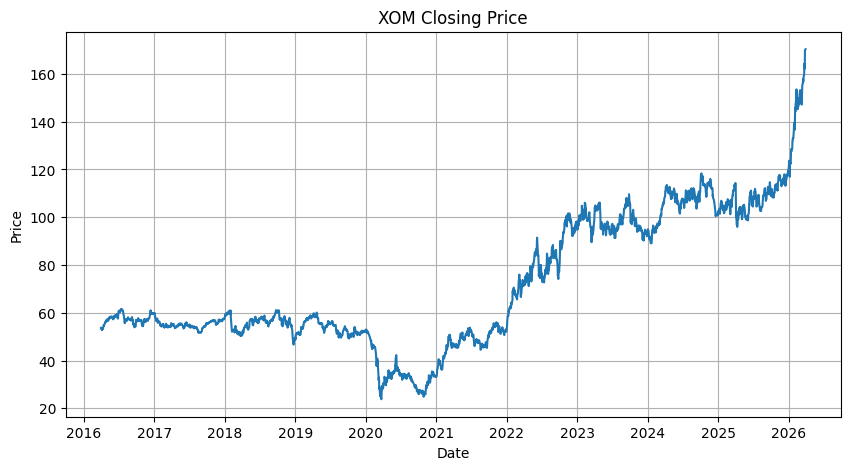

In [3]:
for name, stock in stock_list:
    display(f"Ticker: {name}", stock.head(7))
    plt.figure(figsize=(10, 5))
    plt.plot(stock['Close'])
    plt.title(f'{name} Closing Price')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.grid()
    # plt.savefig(f'./relazione/images/{name}_data_presentation.png')
    plt.show()

# Rendimenti

## Calcolo dei rendimenti semplici e logaritmici

Calcolo dei rendimenti semplici e logaritmici per ogni titolo e visualizzazione dei grafici.

Ticker: GM


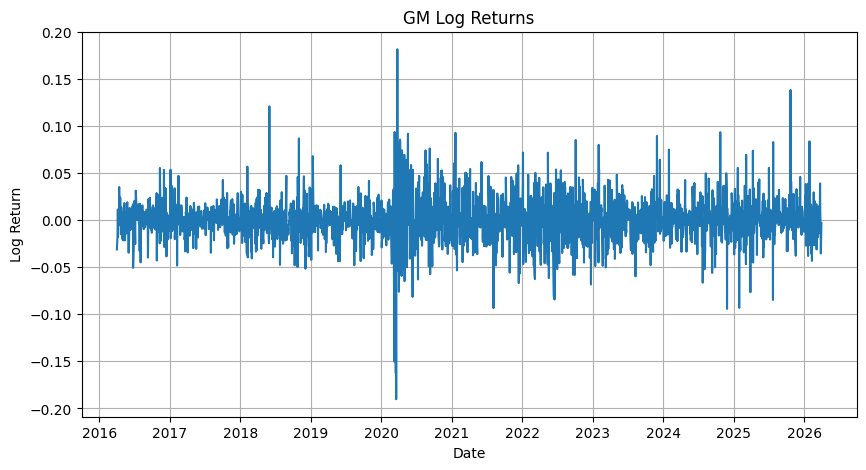

Ticker: MSFT


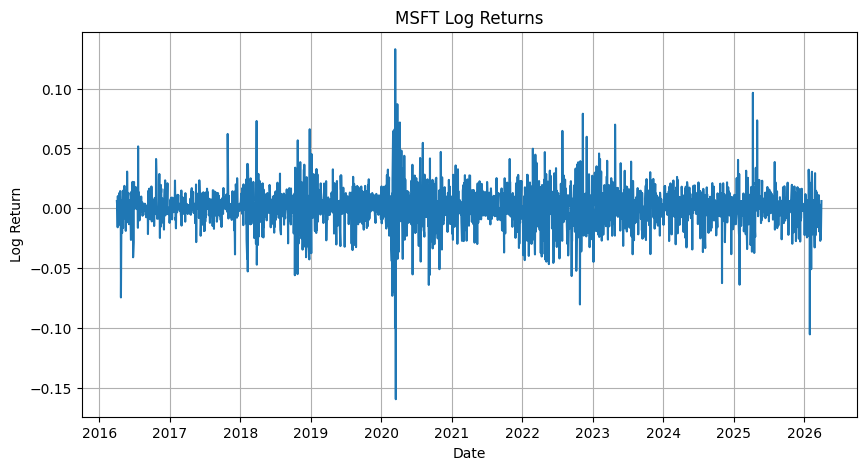

Ticker: NEE


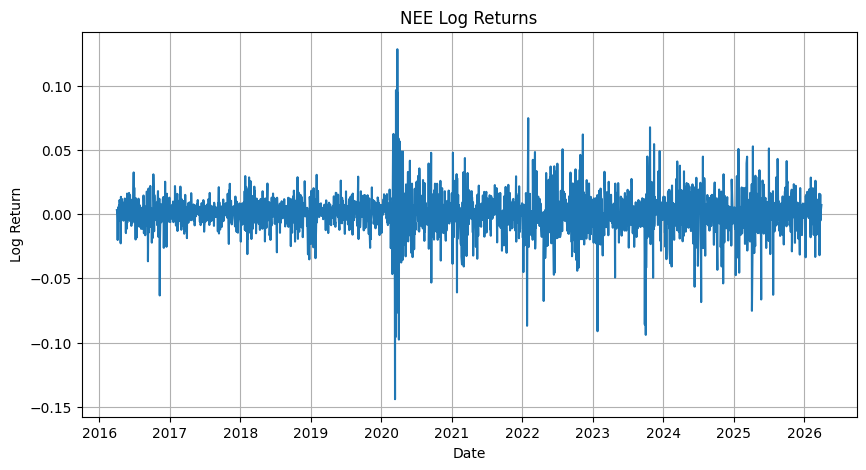

Ticker: NVDA


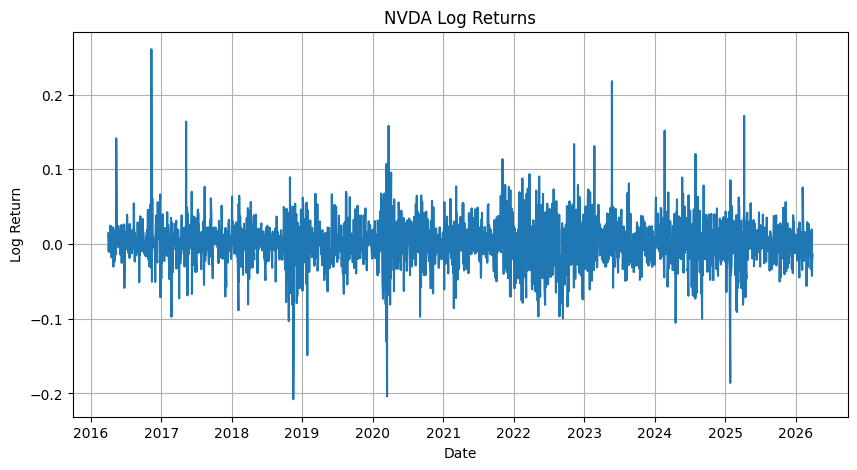

Ticker: TSLA


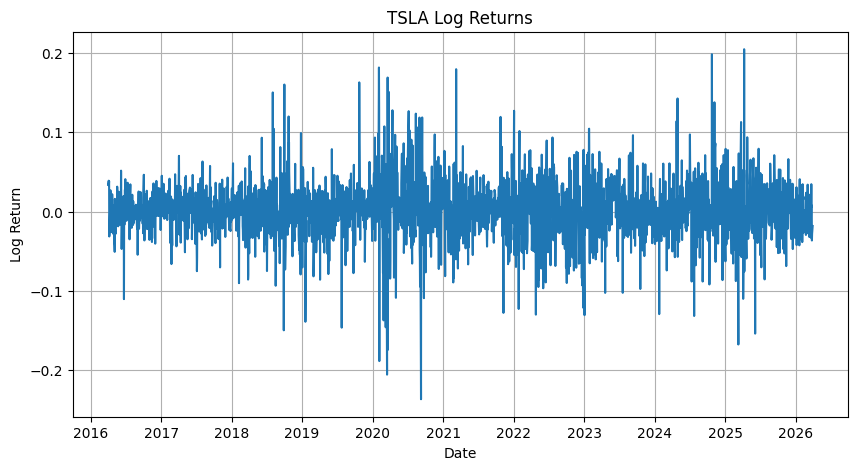

Ticker: XOM


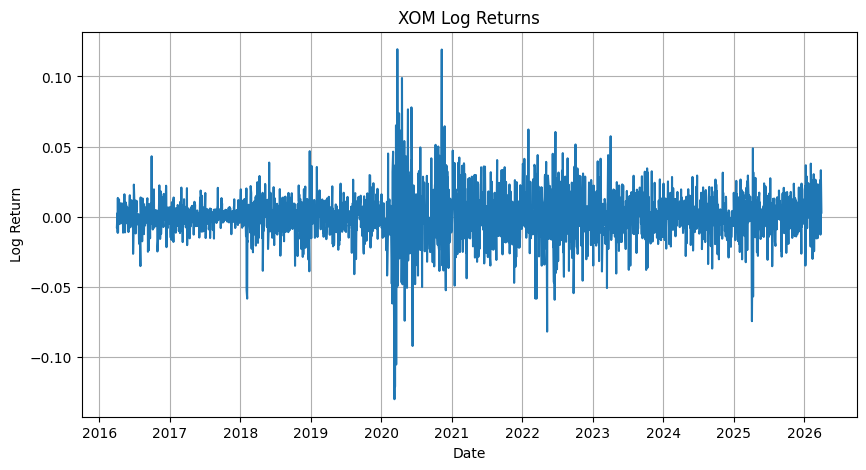

In [4]:
for ticker, df in stock_list:
    print(f"Ticker: {ticker}")
    df['Gross_SR'] = df['Close'] / df['Close'].shift(1)
    df['Net_SR'] = df['Gross_SR'] - 1
    df['LR'] = np.log(df['Gross_SR'])
    plt.figure(figsize=(10, 5))
    plt.plot(df['LR'])
    plt.title(f'{ticker} Log Returns')
    plt.xlabel('Date')
    plt.ylabel('Log Return')
    plt.grid()
    # plt.savefig(f'./relazione/images/{ticker}_log_returns.png')
    plt.show()
    plt.close()

## Calcolo dei rendimenti composti annui e cumulati

Calcolo dei rendimenti composti annui e rendimenti cumulati per ogni titolo.

In [5]:
delta = end_date - start_date
t = delta/dt.timedelta(days=1)
for ticker, df in stock_list:
    df["Cum"] = np.cumprod(df["Gross_SR"])
    cagr = (df['Close'].iloc[-1] / df['Close'].iloc[0]) ** (365 / t) - 1
    print(f'{ticker} CAGR: {cagr:.2%}')
    display(df.tail())

GM CAGR: 11.03%


Price,Close,High,Low,Open,Volume,Gross_SR,Net_SR,LR,Cum
Date,,,,,,,,,
2026-03-24,76.570000,76.870003,74.769997,74.980003,7122200,1.011226,0.011226,0.011163,2.997666
2026-03-25,76.610001,78.290001,76.389999,77.900002,7190700,1.000522,0.000522,0.000522,2.999232
2026-03-26,75.599998,77.169998,74.910004,75.970001,8470900,0.986816,-0.013184,-0.013271,2.959691
2026-03-27,72.980003,75.260002,72.680000,75.209999,7563200,0.965344,-0.034656,-0.035271,2.857120
2026-03-30,72.760002,74.230003,72.419998,73.709999,7192300,0.996985,-0.003015,-0.003019,2.848507


MSFT CAGR: 22.12%


Price,Close,High,Low,Open,Volume,Gross_SR,Net_SR,LR,Cum
Date,,,,,,,,,
2026-03-24,371.934418,381.643400,371.046357,381.533622,42733600,0.973211,-0.026789,-0.027154,7.670135
2026-03-25,370.238129,376.245107,368.831172,376.105426,31181200,0.995439,-0.004561,-0.004571,7.635154
2026-03-26,365.179077,373.910167,364.400764,370.018602,36836600,0.986336,-0.013664,-0.013759,7.530825
2026-03-27,355.998932,361.666679,355.739515,361.117850,37883400,0.974861,-0.025139,-0.025460,7.341509
2026-03-30,358.184204,364.570366,355.510003,361.117853,44797000,1.006138,0.006138,0.006120,7.386575


NEE CAGR: 14.91%


...

Price,Close,High,Low,Open,Volume,Gross_SR,Net_SR,LR,Cum
Date,,,,,,,,,
2026-03-24,175.199997,176.220001,173.979996,174.830002,147667800,0.997495,-0.002505,-0.002508,200.865135
2026-03-25,178.679993,181.220001,176.850006,177.100006,162602100,1.019863,0.019863,0.019668,204.854917
2026-03-26,171.240005,176.509995,171.139999,176.070007,186152200,0.958361,-0.041639,-0.042530,196.325043
2026-03-27,167.520004,170.970001,167.009995,170.000000,196212700,0.978276,-0.021724,-0.021963,192.060096
2026-03-30,165.169998,169.449997,164.270004,168.779999,185627000,0.985972,-0.014028,-0.014128,189.365837


TSLA CAGR: 36.92%


Price,Close,High,Low,Open,Volume,Gross_SR,Net_SR,LR,Cum
Date,,,,,,,,,
2026-03-24,383.029999,387.480011,376.309998,376.559998,60004900,1.005724,0.005724,0.005708,25.005223
2026-03-25,385.950012,396.230011,385.010010,389.989990,55157300,1.007623,0.007623,0.007595,25.195849
2026-03-26,372.109985,384.440002,371.869995,381.600006,55522900,0.964140,-0.035860,-0.036518,24.292335
2026-03-27,361.829987,369.859985,359.470001,369.690002,62065700,0.972374,-0.027626,-0.028015,23.621229
2026-03-30,355.279999,367.290009,352.140015,365.859985,67954400,0.981898,-0.018102,-0.018268,23.193629


XOM CAGR: 12.23%


Price,Close,High,Low,Open,Volume,Gross_SR,Net_SR,LR,Cum
Date,,,,,,,,,
2026-03-24,164.265060,166.350894,160.162899,160.619804,26131800,1.026376,0.026376,0.026034,3.058615
2026-03-25,162.159348,163.887622,161.831570,162.765236,17192300,0.987181,-0.012819,-0.012902,3.019407
2026-03-26,164.314713,164.563027,160.967437,162.983750,18625200,1.013292,0.013292,0.013204,3.059540
2026-03-27,169.837234,170.075607,163.688963,164.463704,30338300,1.033609,0.033609,0.033057,3.162369
2026-03-30,170.313995,175.220694,169.896829,171.346977,29813500,1.002807,0.002807,0.002803,3.171246


## Grafici diagnostici

Creazione di grafici diagnostici a 3 sezioni (istogramma e kernel density, boxplot, qq-plot) per
ciascuna serie di rendimenti

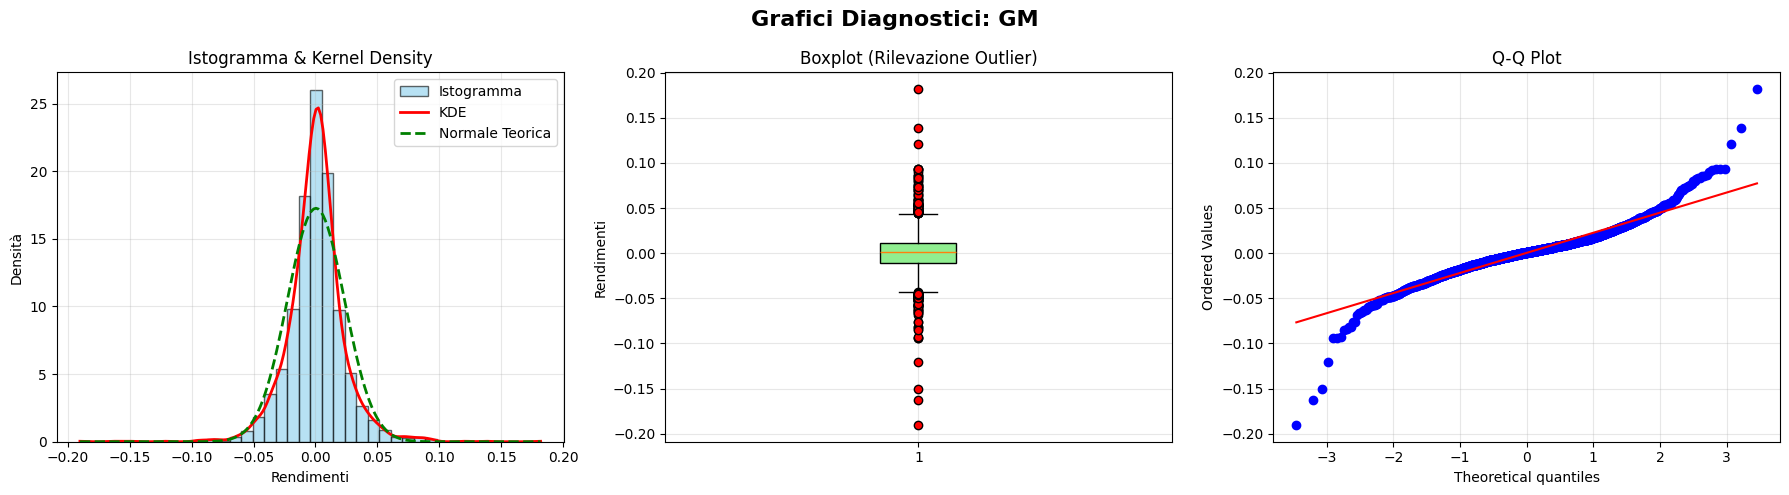

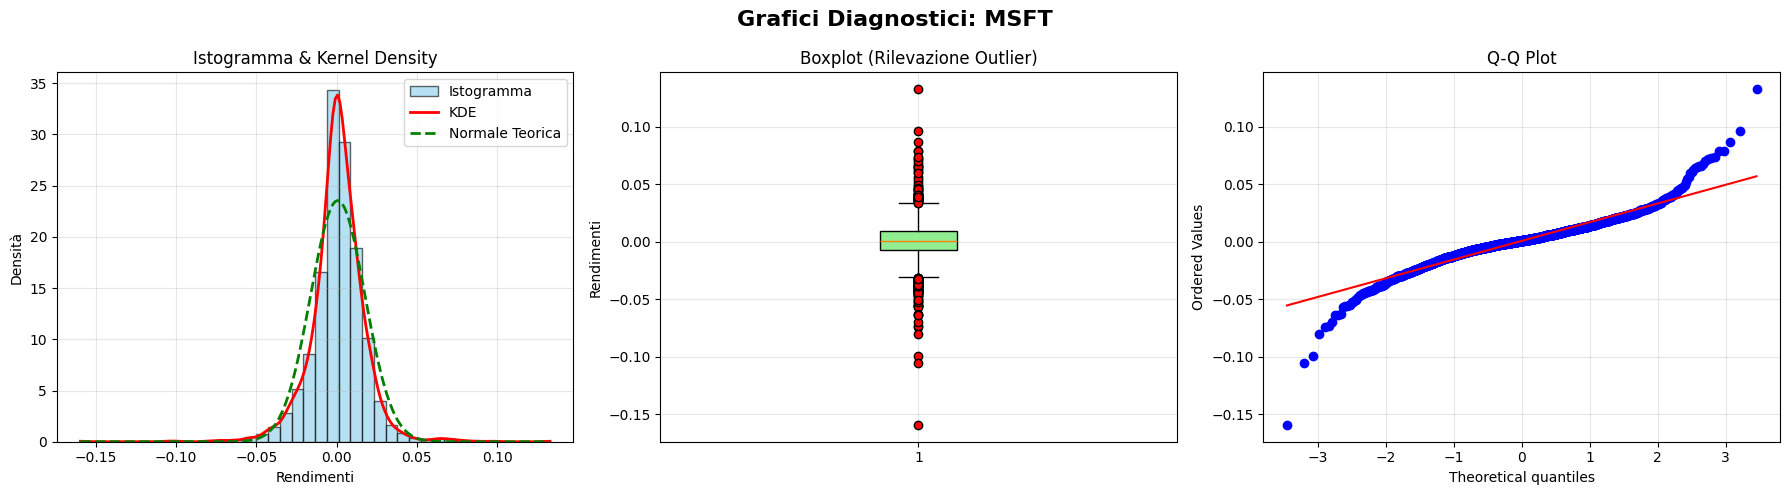

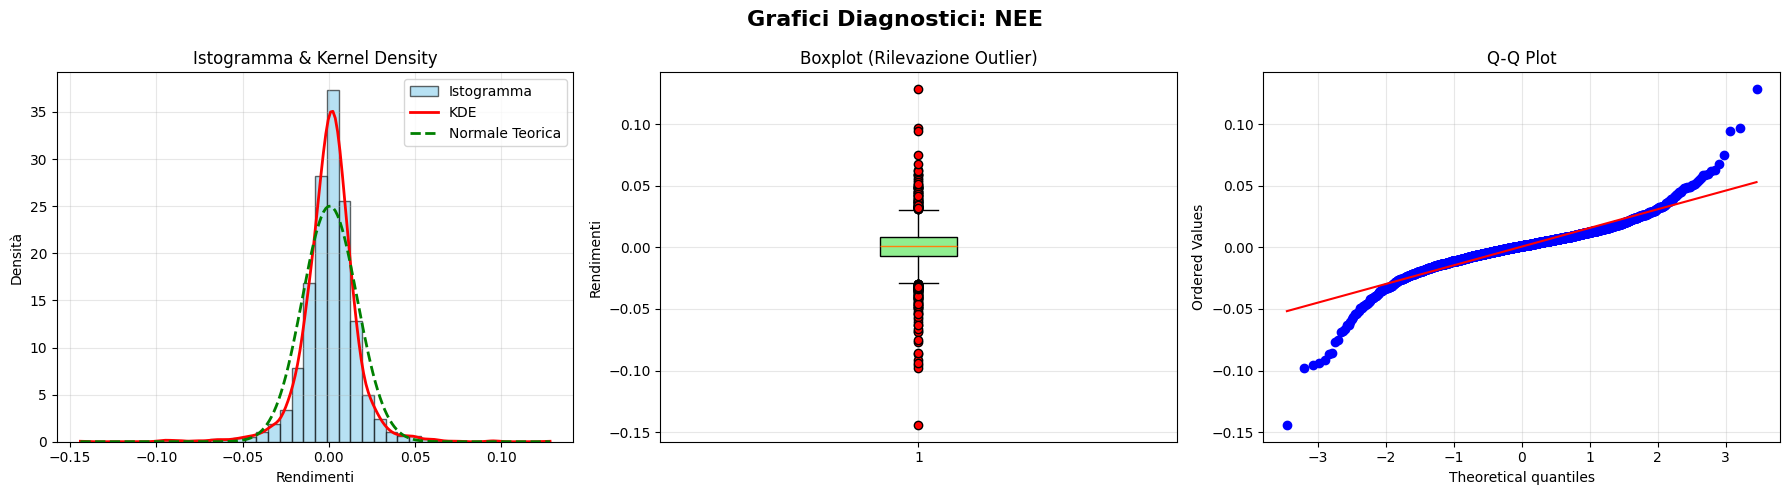

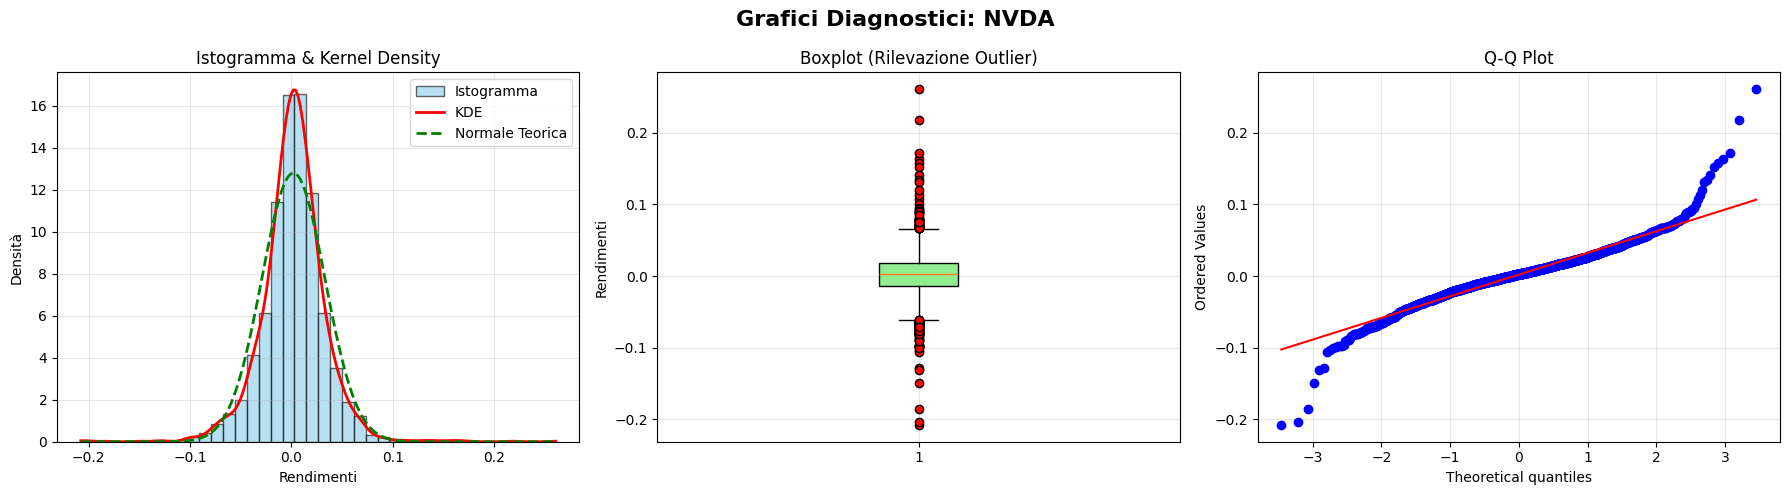

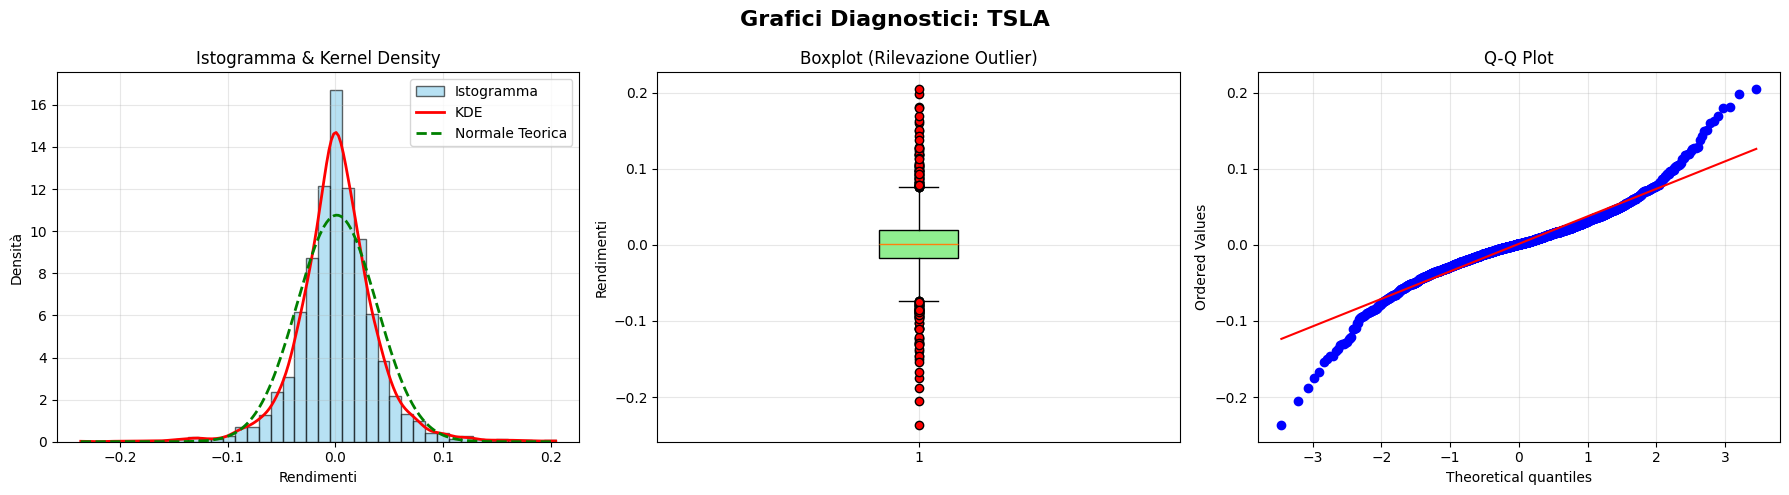

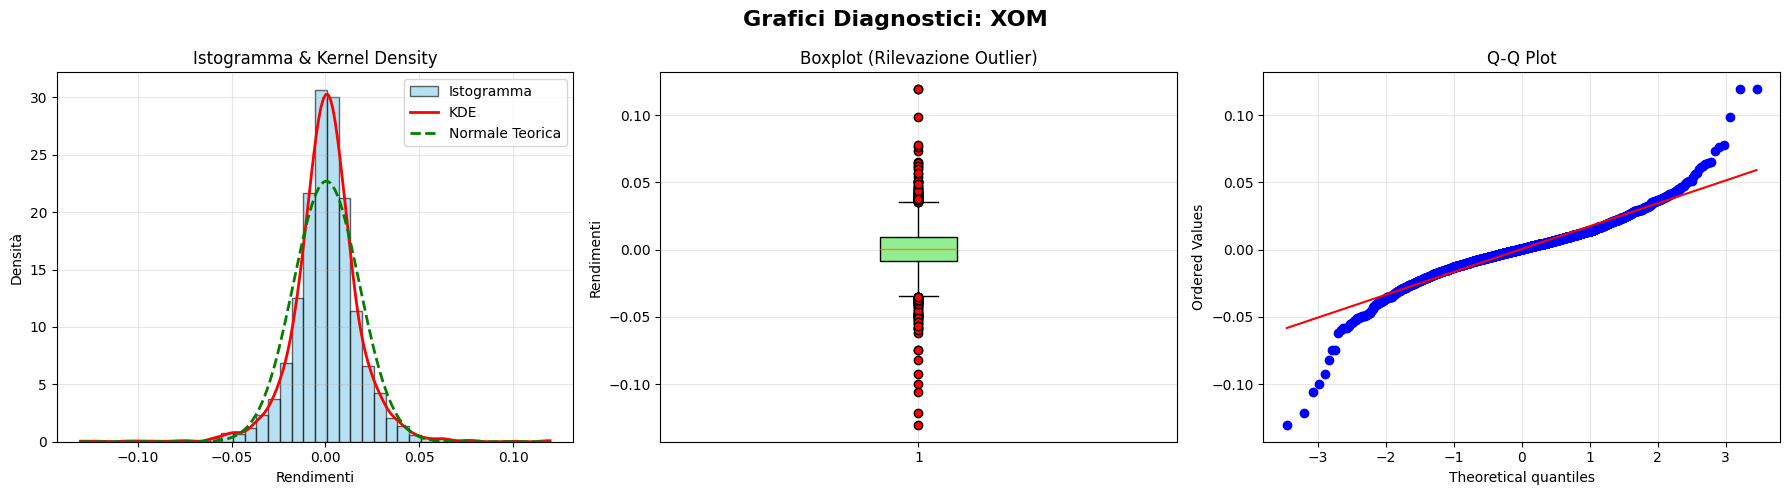

In [6]:
for ticker, df in stock_list:
    df_clean = df.dropna(subset=["LR"])
    # Creazione della figura con 3 sotto-grafici in linea
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(
        f"Grafici Diagnostici: {ticker}", fontsize=16, fontweight="bold"
    )

    # Sezione 1: Istogramma e Kernel Density (KDE)
    axes[0].hist(
        df_clean["LR"],
        bins=40,
        density=True,
        alpha=0.6,
        color="skyblue",
        edgecolor="black",
        label="Istogramma",
    )
    # Linea KDE
    kde = stats.gaussian_kde(df_clean["LR"])
    x_range = np.linspace(df_clean["LR"].min(), df_clean["LR"].max(), 200)
    axes[0].plot(x_range, kde(x_range), color="red", lw=2, label="KDE")
    # Linea Normale teorica per confronto
    mu, std = df_clean["LR"].mean(), df_clean["LR"].std()
    axes[0].plot(
        x_range,
        stats.norm.pdf(x_range, mu, std),
        color="green",
        linestyle="--",
        lw=2,
        label="Normale Teorica",
    )
    axes[0].set_title("Istogramma & Kernel Density")
    axes[0].set_xlabel("Rendimenti")
    axes[0].set_ylabel("Densità")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Sezione 2: Boxplot
    axes[1].boxplot(
        df_clean["LR"],
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor="lightgreen", color="black"),
        flierprops=dict(
            marker="o",
            markerfacecolor="red",
            markersize=6,
            linestyle="none",
        ),
    )
    axes[1].set_title("Boxplot (Rilevazione Outlier)")
    # axes[1].set_xticklabels(ticker)
    axes[1].set_ylabel("Rendimenti")
    axes[1].grid(True, alpha=0.3)

    # Sezione 3: Q-Q Plot
    stats.probplot(df_clean["LR"], dist="norm", plot=axes[2])
    axes[2].set_title("Q-Q Plot")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    # plt.savefig(f'./relazione/images/{ticker}_diagnostic_plots.png')
    plt.show()
    plt.close()

## Analisi univariata dei rendimenti
Analisi univariata dei rendimenti, con calcolo di media, varianza, deviazione standard, skewness e kurtosis (annualizzati).

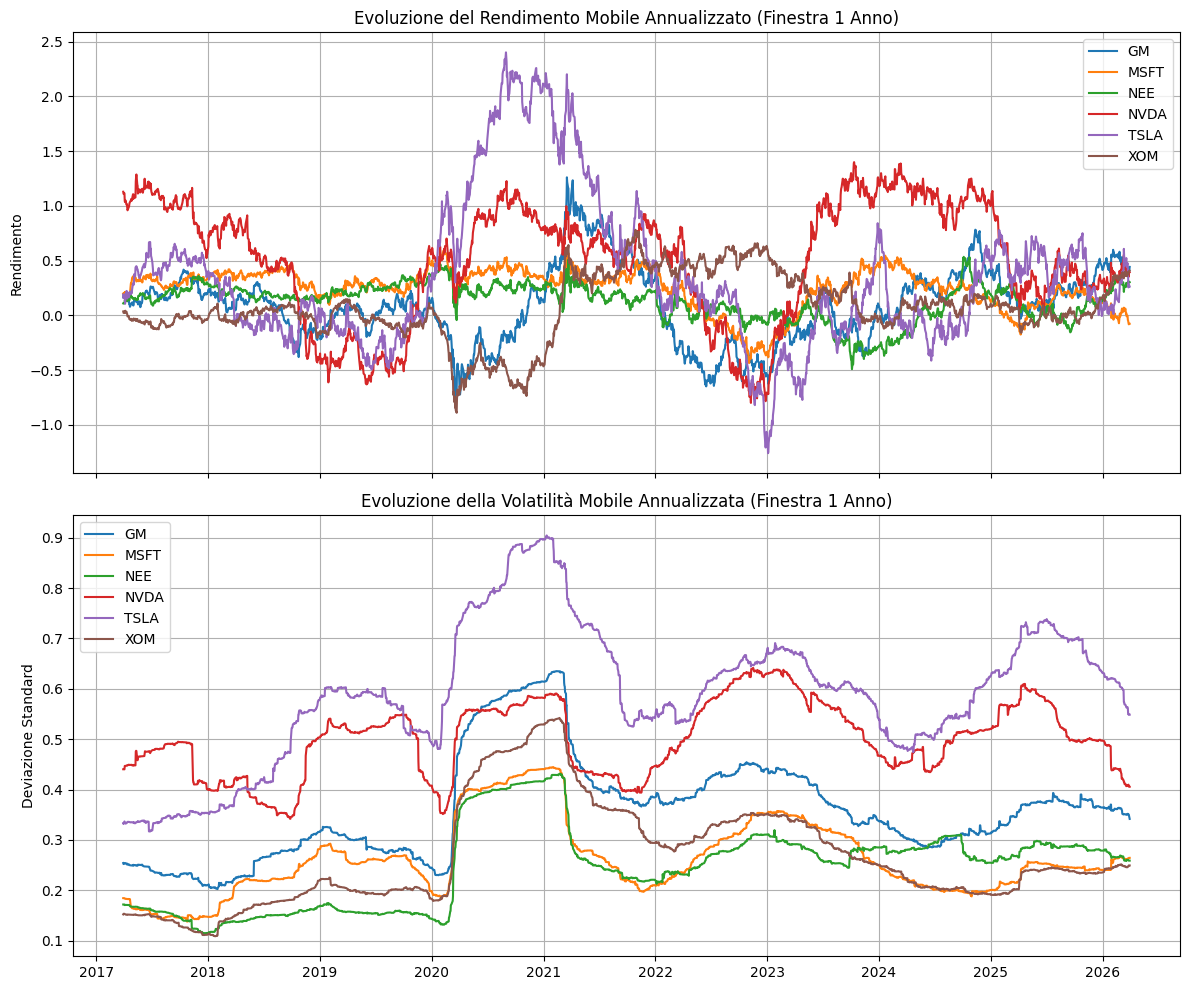

--- TABELLA DELLE STATISTICHE DESCRITTIVE ---


,Media Annualizzata,Varianza Annualizzata,Deviazione Standard Annualizzata,Asimmetria (Skewness),Curtosi in eccesso,Distanza da Normale
GM,0.104971,0.134599,0.366877,-0.060493,7.304740,7.304990
MSFT,0.200523,0.072286,0.268861,-0.260879,8.262387,8.266505
NEE,0.139415,0.064080,0.253141,-0.532200,9.570356,9.585142
NVDA,0.525829,0.245151,0.495127,0.100841,6.670911,6.671673
TSLA,0.315263,0.346177,0.588368,-0.046746,4.278325,4.278580
XOM,0.115734,0.077838,0.278995,-0.224439,6.496250,6.500126


In [7]:
report = {}
window_size = 252
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

for ticker, df in stock_list:
    df_clean = df.dropna(subset=["LR"])

    # Calcolo delle statistiche annualizzate complessive
    mean = df_clean["LR"].mean() * 252
    variance = df_clean["LR"].var() * 252
    std_dev = np.sqrt(variance)
    skewness = stats.skew(df_clean["LR"])
    kurtosis = stats.kurtosis(df_clean["LR"]) # Curtosi in eccesso (0 = Normale)

    # Calcolo della distanza geometrica dalla distribuzione Normale (0,0)
    dist_normale = np.sqrt(skewness**2 + kurtosis**2)

    report[ticker] = {
        "Media Annualizzata": mean,
        "Varianza Annualizzata": variance,
        "Deviazione Standard Annualizzata": std_dev,
        "Asimmetria (Skewness)": skewness,
        "Curtosi in eccesso": kurtosis,
        "Distanza da Normale": dist_normale
    }

    # Rendimento e volatilità mobile annualizzate
    df_clean["Rolling_Mean"] = df_clean["LR"].rolling(window=window_size).mean() * 252
    df_clean["Rolling_Vol"] = df_clean["LR"].rolling(window=window_size).std() * np.sqrt(252)

    # Grafico Rendimento e Volatilità nel tempo
    ax1.plot(df_clean.index, df_clean["Rolling_Mean"], label=ticker)
    ax2.plot(df_clean.index, df_clean["Rolling_Vol"], label=ticker)

# Finalizzazione dei grafici dell'evoluzione temporale
ax1.set_title("Evoluzione del Rendimento Mobile Annualizzato (Finestra 1 Anno)")
ax1.set_ylabel("Rendimento")
ax1.legend()
ax1.grid(True)

ax2.set_title("Evoluzione della Volatilità Mobile Annualizzata (Finestra 1 Anno)")
ax2.set_ylabel("Deviazione Standard")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
# plt.savefig(f'./relazione/images/moving_averages_volatility.png')
plt.show()

# Creazione DataFrame per la tabella delle statistiche descrittive
df_report = pd.DataFrame(report).T
print("--- TABELLA DELLE STATISTICHE DESCRITTIVE ---")
display(df_report)

## Correlazione tra rendimenti

Calcolo della matrice di varianze/covarianze e di correlazione dei rendimenti mensili dei titoli.

In [8]:
# Creazione DataFrame con i rendimenti logaritmici di tutti i titoli
df_lr = pd.DataFrame({ticker: df['LR'] for ticker, df in stock_list})
df_lr.dropna(inplace=True)

# Aggregazione mensile sommando i rendimenti logaritmici
df_m = df_lr.groupby(pd.Grouper(freq='ME')).sum()

# Calcolo matrice di Varianza/Covarianza dei rendimenti mensili
mat_cov = df_m.cov()

# Calcolo matrice di Correlazione dei rendimenti mensili
mat_corr = df_m.corr()

print("--- MATRICE DI VARIANZA/COVARIANZA MENSILE ---")
print(mat_cov)
print("\n--- MATRICE DI CORRELAZIONE MENSILE ---")
print(mat_corr)

--- MATRICE DI VARIANZA/COVARIANZA MENSILE ---
            GM      MSFT       NEE      NVDA      TSLA       XOM
GM    0.009170  0.001641  0.000784  0.005048  0.005782  0.003290
MSFT  0.001641  0.003570  0.000883  0.005087  0.004045  0.000234
NEE   0.000784  0.000883  0.003792  0.001371  0.001325 -0.000082
NVDA  0.005048  0.005087  0.001371  0.017741  0.007357  0.001206
TSLA  0.005782  0.004045  0.001325  0.007357  0.028481  0.000342
XOM   0.003290  0.000234 -0.000082  0.001206  0.000342  0.006382

--- MATRICE DI CORRELAZIONE MENSILE ---
            GM      MSFT       NEE      NVDA      TSLA       XOM
GM    1.000000  0.286772  0.132970  0.395759  0.357784  0.430045
MSFT  0.286772  1.000000  0.240033  0.639104  0.401102  0.049015
NEE   0.132970  0.240033  1.000000  0.167125  0.127509 -0.016583
NVDA  0.395759  0.639104  0.167125  1.000000  0.327287  0.113332
TSLA  0.357784  0.401102  0.127509  0.327287  1.000000  0.025395
XOM   0.430045  0.049015 -0.016583  0.113332  0.025395  1.000000


## Correlazione nel tempo

Creazione di scatter plot per visualizzare la relazione tra i rendimenti di coppie di titoli dello stesso settore.

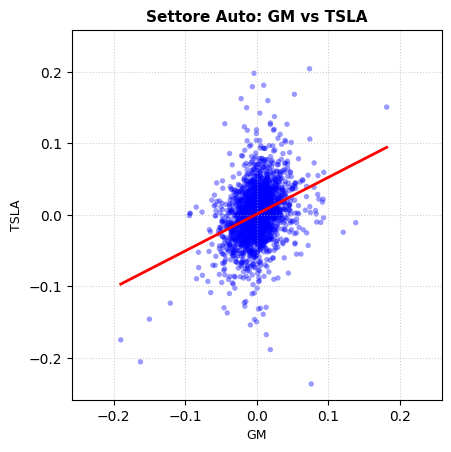

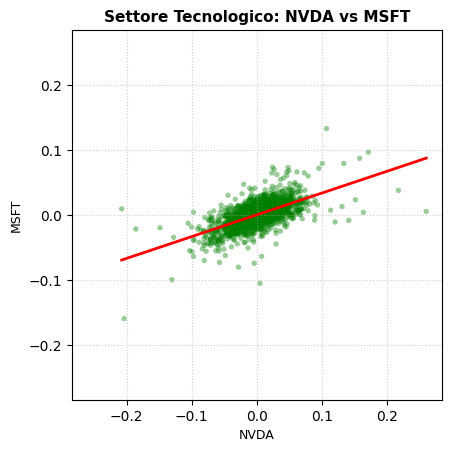

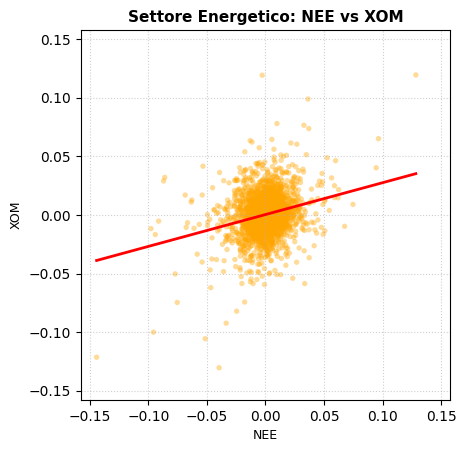

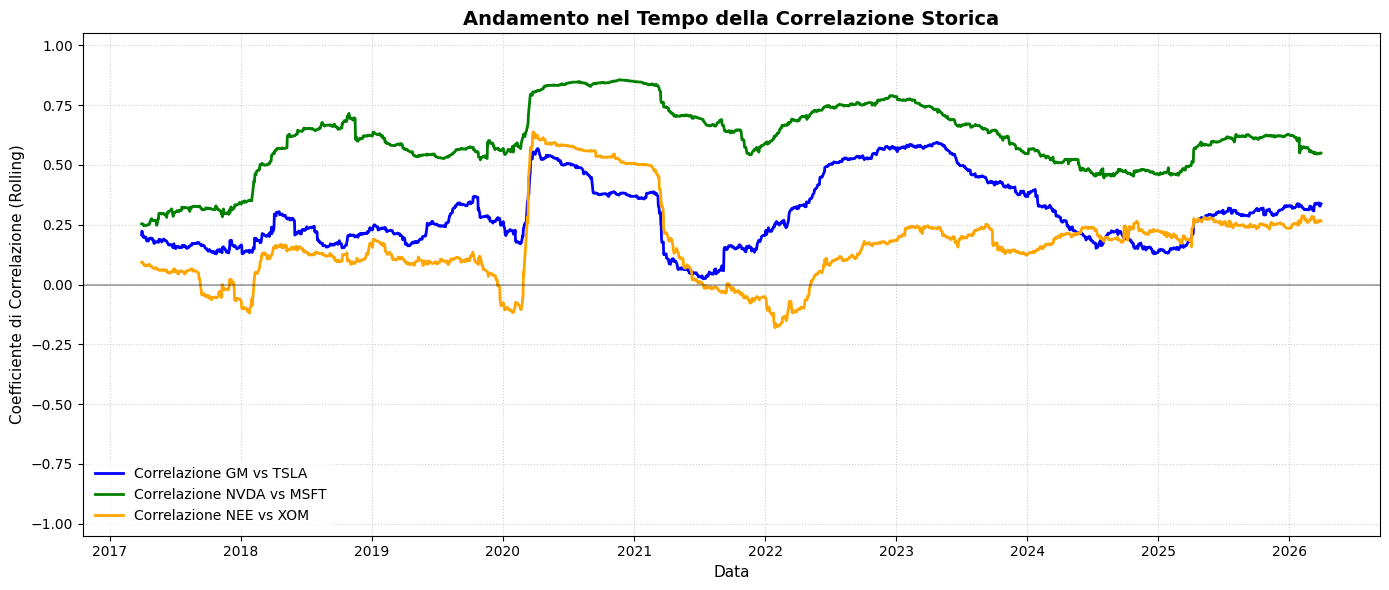

In [9]:
# Settore Auto: GM vs TSLA
utils.plot_scatter(
    df_lr['GM'],
    df_lr['TSLA'], 
    'blue',
    'Settore Auto: GM vs TSLA',
    'GM',
    'TSLA'
)

# Settore Tech: NVDA vs MSFT
utils.plot_scatter(
    df_lr['NVDA'], 
    df_lr['MSFT'], 
    'green', 
    'Settore Tecnologico: NVDA vs MSFT', 
    'NVDA', 
    'MSFT'
)

# Settore Energia: NEE vs XOM
utils.plot_scatter(
    df_lr['NEE'], 
    df_lr['XOM'], 
    'orange', 
    'Settore Energetico: NEE vs XOM', 
    'NEE', 
    'XOM'
)

# Grafico della correlazione storica con finestra mobile
finestra_giorni = 252

rolling_auto = df_lr['GM'].rolling(window=finestra_giorni).corr(df_lr['TSLA'])
rolling_tech = df_lr['NVDA'].rolling(window=finestra_giorni).corr(df_lr['MSFT'])
rolling_energy = df_lr['NEE'].rolling(window=finestra_giorni).corr(df_lr['XOM'])

plt.figure(figsize=(14, 6))
plt.plot(rolling_auto, label='Correlazione GM vs TSLA', color='blue', lw=2)
plt.plot(rolling_tech, label='Correlazione NVDA vs MSFT', color='green', lw=2)
plt.plot(rolling_energy, label='Correlazione NEE vs XOM', color='orange', lw=2)

plt.title('Andamento nel Tempo della Correlazione Storica', fontsize=14, fontweight='bold')
plt.xlabel('Data', fontsize=11)
plt.ylabel('Coefficiente di Correlazione (Rolling)', fontsize=11)
plt.ylim(-1.05, 1.05)
plt.axhline(0, color='black', linestyle='-', alpha=0.3)
plt.legend(loc='lower left', frameon=True, facecolor='white', edgecolor='none')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
# plt.savefig(f'./relazione/images/rolling_correlation_same_sector3.png')
plt.show()


# CAPM

## Stima del beta
Stima del beta per ogni titolo, utilizzando i rendimenti del S&P 500 come benchmark.

In [10]:
# Download dati S&P 500 per stima beta
SP500 = yf.download('^GSPC', start=start_date, end=end_date, progress=False)

# Creazione DataFrame con i prezzi di chiusura di tutti i titoli e S&P 500
df_closes = pd.DataFrame({ticker: df['Close'] for ticker, df in stock_list})
df_closes['SP500'] = SP500['Close']

# Calcolo dei rendimenti mensili
df_NSR_monthly = df_closes.resample('ME').last().pct_change().dropna()

X = df_NSR_monthly.pop('SP500')
betas = {}

# Stima del beta per ogni titolo tramite regressione lineare OLS
for ticker in df_NSR_monthly.columns:
    X = sm.add_constant(X)
    y = df_NSR_monthly[ticker]
    model = sm.OLS(y, X).fit()
    betas[ticker] = model.params['SP500']

betas_df = pd.DataFrame.from_dict(
    betas,
    orient='index',
    columns=['Beta']
)

print(betas_df)

          Beta
GM    1.351630
MSFT  0.965276
NEE   0.463090
NVDA  1.859838
TSLA  1.968334
XOM   0.814672


## Rendimento atteso annuo

Calcolo del rendimento atteso annuo per ogni titolo, utilizzando la formula del CAPM con il beta appena stimato

In [11]:
# Stima del rendimento atteso annuo del mercato (S&P 500) tramite media geometrica
n_mesi = len(X['SP500'])
rm_total_growth = (1 + X['SP500']).prod()
rm_annual = (rm_total_growth) ** (12 / n_mesi) - 1
print(f'Rendimento atteso annuo del mercato (S&P 500): {rm_annual:.2%}')

# Calcolo del rendimento senza rischio (T-Bill)

## Incompatibilità e Risoluzione delle Librerie di Rilevamento Dati
## Durante l'importazione dei dati finanziari con pandas-datareader, sono emerse due criticità software dovute 
## al mancato aggiornamento della libreria rispetto agli standard di Python 3.12+ e delle versioni recenti di 
## pandas:
## - Rimozione di distutils (ModuleNotFoundError): Python 3.12+ ha eliminato definitivamente il modulo distutils. 
## pandas-datareader fallisce all'avvio poiché tenta ancora di importarlo internamente per gestire la verifica delle 
## versioni (LooseVersion).
## - Mutazione delle API di pandas (TypeError): Nelle ultime versioni di pandas, il decoratore 
## @deprecate_kwarg ha introdotto l'argomento obbligatorio new_arg_name. Il vecchio codice di pandas-datareader non 
## fornisce questo parametro, causando un blocco a runtime.

## Gli errori non sono stati risolvibili nemmeno tramite l'installazione di 'setuptools', che è una delle 
## soluzioni temporanee suggerite per la rimozione di distutils.

# rf_data = web.DataReader(
#     'DGS1',
#     'fred',
#     start_date,
#     end_date
# )
# rf = rf_data.iloc[-1,0] / 100

## Dati i problemi di accesso ai dati storici dei T-Bill, utilizziamo un valore fisso.
### May 28, 2026 (https://ycharts.com/indicators/1_year_treasury_rate)
rf_annual = 0.038 
print(f'Rendimento senza rischio (T-Bill): {rf_annual:.2%}')

# Calcolo del rendimento atteso annuo per ogni titolo utilizzando la formula del CAPM
capm_returns = betas_df.copy()

capm_returns['Expected Return'] = (rf_annual + capm_returns['Beta'] * (rm_annual - rf_annual))

print(capm_returns)

Rendimento atteso annuo del mercato (S&P 500): 11.91%
Rendimento senza rischio (T-Bill): 3.80%
          Beta  Expected Return
GM    1.351630         0.147562
MSFT  0.965276         0.116245
NEE   0.463090         0.075538
NVDA  1.859838         0.188757
TSLA  1.968334         0.197552
XOM   0.814672         0.104037


## Esposizione ai fattori di rischio Fama-French
Stima dell'esposizione di ogni titolo ai fattori di rischio Fama-French (Mkt-RF, SMB, HML, RMW, CMA) utilizzando i rendimenti mensili e i dati dei fattori scaricati da Kenneth French Data Library.

Calcolo dell'esposizione ai fattori di rischio Fama-French con finestra mobile, per analizzare come l'esposizione ai fattori cambia nel tempo.

In [12]:
# Download dei dati dei fattori di rischio Fama-French
url = 'https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_CSV.zip'
zip_path = 'F-F_Research_Data_5_Factors_2x3_CSV.zip'

urllib.request.urlretrieve(url, zip_path)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall('./data')

os.remove(zip_path)

# Caricamento dei dati dei fattori di rischio Fama-French
ff = pd.read_csv(
    './data/F-F_Research_Data_5_Factors_2x3.csv',
    skiprows=3
)

ff = ff.rename(columns={ff.columns[0]: 'Date'})

# mantieni solo le righe con data numerica
ff = ff[ff['Date'].astype(str).str.isnumeric()]

ff['Date'] = ff['Date'].astype(str)

# converte da percentuale a decimale
for col in ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']:
    ff[col] = ff[col].astype(float) / 100

# Preparazione degli indici per il join dei dataframe
ff.index = pd.to_datetime(ff['Date'].astype(str), format='%Y%m').dt.strftime('%Y-%m')
ff = ff.drop(columns=['Date'])
df_NSR_monthly.index = pd.to_datetime(df_NSR_monthly.index).strftime('%Y-%m')

ff_results = {}

# Stima dell'esposizione ai fattori di rischio Fama-French per ogni titolo tramite regressione lineare OLS
for col in df_NSR_monthly.columns:
    data = ff.join(df_NSR_monthly[[col]], how='inner').dropna()
    data['excess_rtn'] = data[col] - data['RF']
    model = smf.ols('excess_rtn ~ Q("Mkt-RF") + SMB + HML + RMW + CMA', data=data).fit()
    ff_results[col] = model.params

ff_exposure = pd.DataFrame(ff_results).T
print(ff_exposure)

      Intercept  Q("Mkt-RF")       SMB       HML       RMW       CMA
GM    -0.000173     1.243221  0.428587  0.619415 -0.280949 -0.226080
MSFT   0.005380     1.010137 -0.496512 -0.449699  0.174415 -0.068951
NEE    0.006200     0.453774 -0.021039 -0.341325  0.392081  0.220475
NVDA   0.032394     1.789595 -0.313470 -0.696859  0.235468 -0.730625
TSLA   0.022245     1.837465  0.604077 -1.117190 -0.258119 -0.488632
XOM    0.002798     0.844770  0.160066  0.828455 -0.059058  0.565704


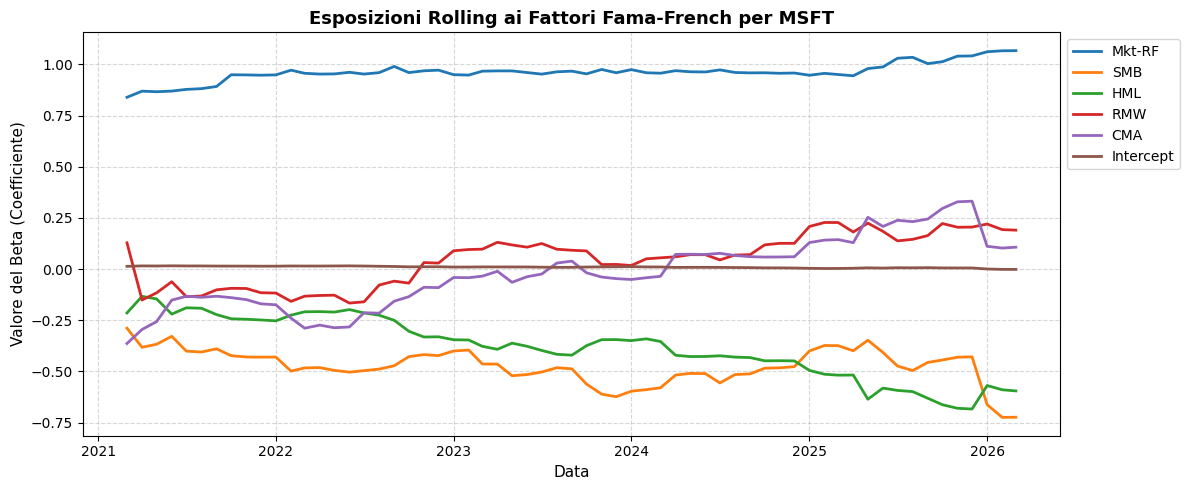

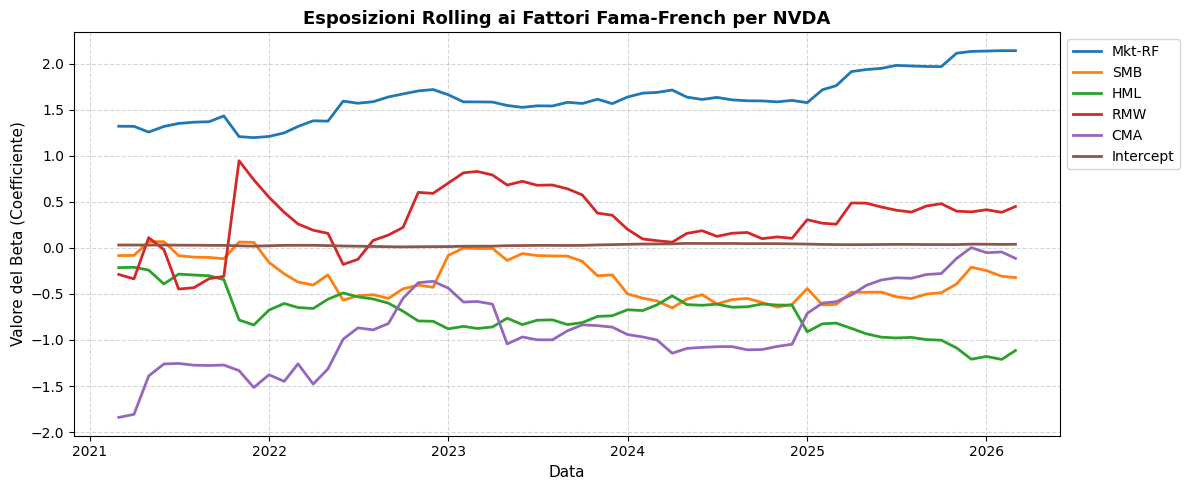

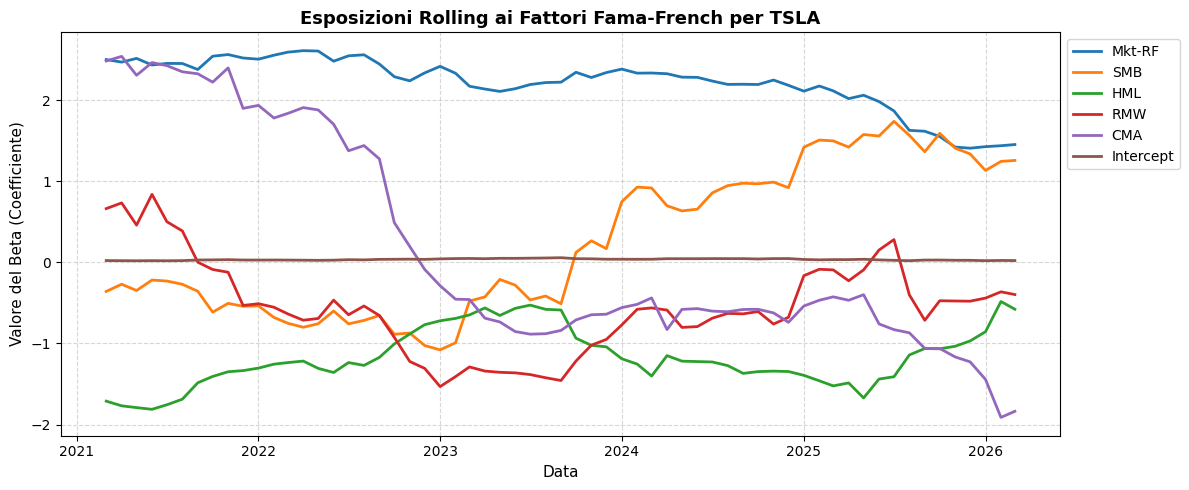

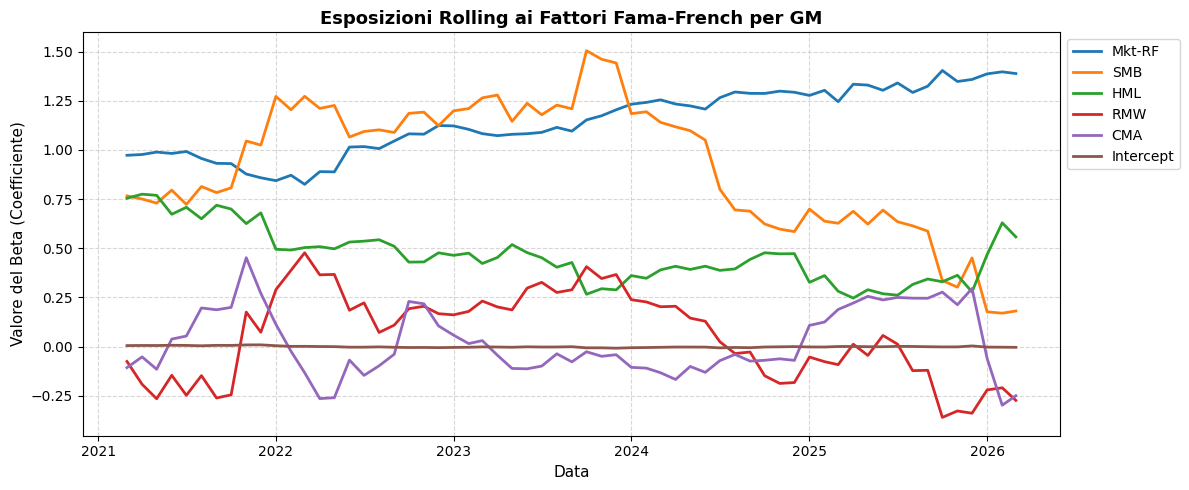

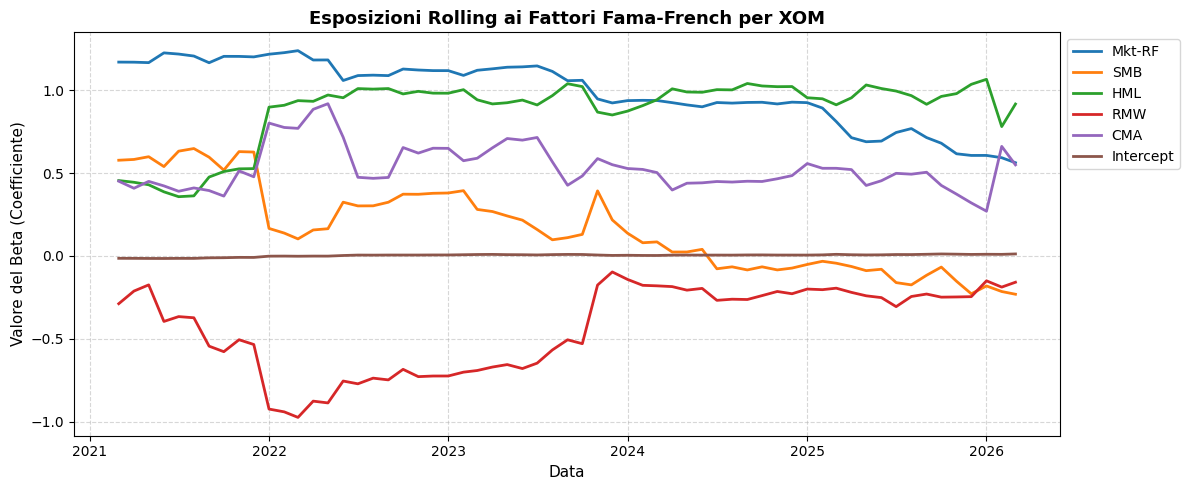

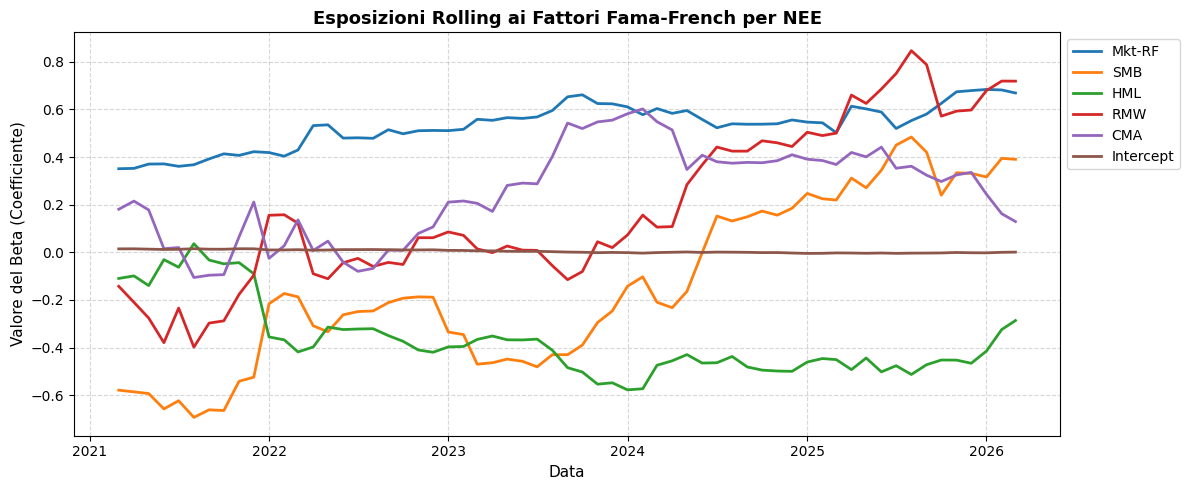

In [13]:
# Preparazione dei dati
data = ff.join(df_NSR_monthly, how='inner').dropna()
data[stocks] = data[stocks].sub(data["RF"], axis=0)

# Calcolo dell'esposizione ai fattori di rischio Fama-French con finestra mobile
ff_factors = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']
ff_rolling_exposure = utils.calcola_esposizione_rolling_multi_titoli(
    data, asset_cols=stocks, factor_cols=ff_factors, window=60
)

# rename colonna Mkt-RF per compatibilità con il codice di visualizzazione
ff_rolling_exposure.rename(columns={'Q("Mkt-RF")': 'Mkt-RF'}, inplace=True)

# Visualizzazione grafica dell'esposizione ai fattori di rischio Fama-French nel tempo
utils.plot_fama_french_rolling_exposure(ff_rolling_exposure, stocks, ff_factors + ['Intercept'])